In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style mặc định cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# Đọc và gộp 2 tập dữ liệu
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

df_mat['subject'] = 'Math'
df_por['subject'] = 'Por'
df = pd.concat([df_mat, df_por], ignore_index=True)

print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.\n")

# Kiểm tra dữ liệu thiếu (Missing values)
missing_values = df.isnull().sum().sum()
print(f"Tổng số giá trị bị thiếu trong toàn bộ dữ liệu: {missing_values}")

# Xem các thông số thống kê cơ bản (Trung bình, độ lệch chuẩn, Min, Max...) của các cột số
display(df.describe().round(2))

Kích thước dữ liệu: 1044 dòng, 34 cột.

Tổng số giá trị bị thiếu trong toàn bộ dữ liệu: 0


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,16.73,2.60,2.39,1.52,1.97,0.26,3.94,3.20,3.16,1.49,2.28,3.54,4.43,11.21,11.25,11.34
std,1.24,1.12,1.10,0.73,0.83,0.66,0.93,1.03,1.15,0.91,1.29,1.42,6.21,2.98,3.29,3.86
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,9.00,9.00,10.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


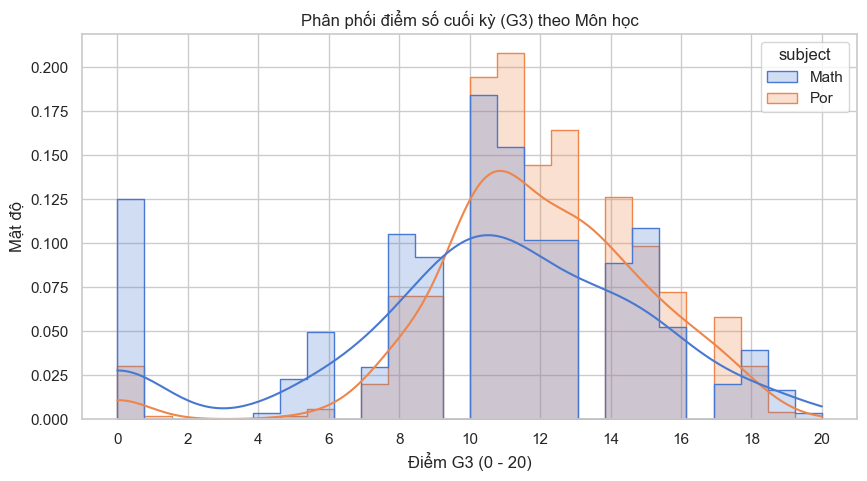

In [2]:
plt.figure(figsize=(10, 5))

# Vẽ biểu đồ phân phối (Histogram + Đường cong mật độ KDE)
sns.histplot(data=df, x='G3', hue='subject', element='step', stat='density', common_norm=False, kde=True, palette='muted')

plt.title('Phân phối điểm số cuối kỳ (G3) theo Môn học')
plt.xlabel('Điểm G3 (0 - 20)')
plt.ylabel('Mật độ')
plt.xticks(range(0, 21, 2))
plt.show()

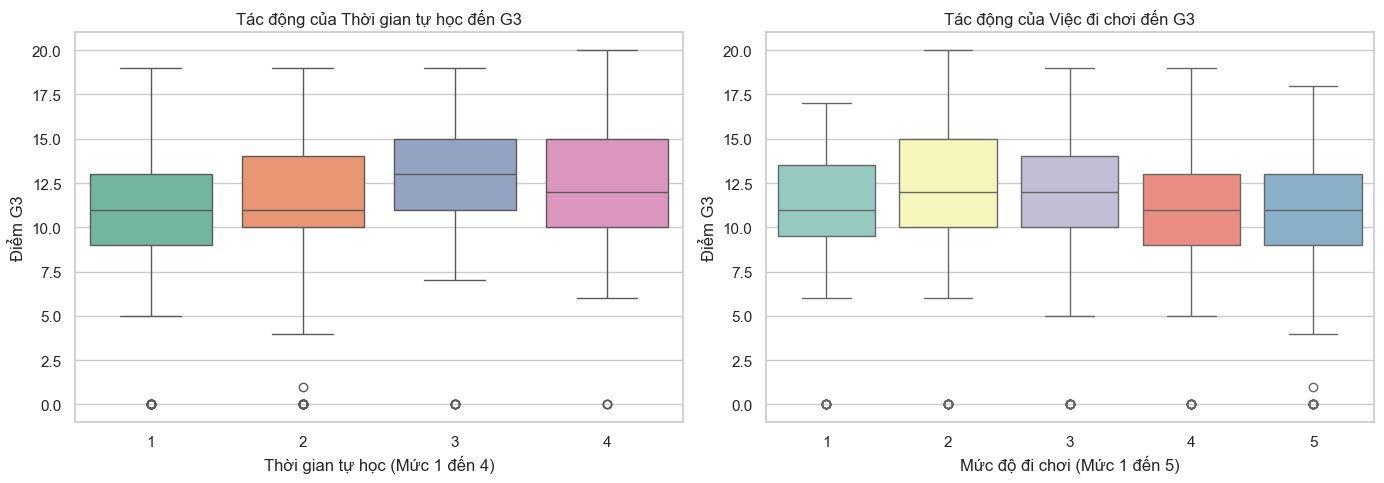

In [6]:
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Thời gian học (studytime: 1=<2h, 2=2-5h, 3=5-10h, 4=>10h)
sns.boxplot(ax=axes[0], x='studytime', y='G3', data=df, palette='Set2')
axes[0].set_title('Tác động của Thời gian tự học đến G3')
axes[0].set_xlabel('Thời gian tự học (Mức 1 đến 4)')
axes[0].set_ylabel('Điểm G3')

# Biểu đồ 2: Đi chơi với bạn bè (goout: 1=Rất ít ... 5=Rất nhiều)
sns.boxplot(ax=axes[1], x='goout', y='G3', data=df, palette='Set3')
axes[1].set_title('Tác động của Việc đi chơi đến G3')
axes[1].set_xlabel('Mức độ đi chơi (Mức 1 đến 5)')
axes[1].set_ylabel('Điểm G3')

plt.tight_layout()
plt.show()

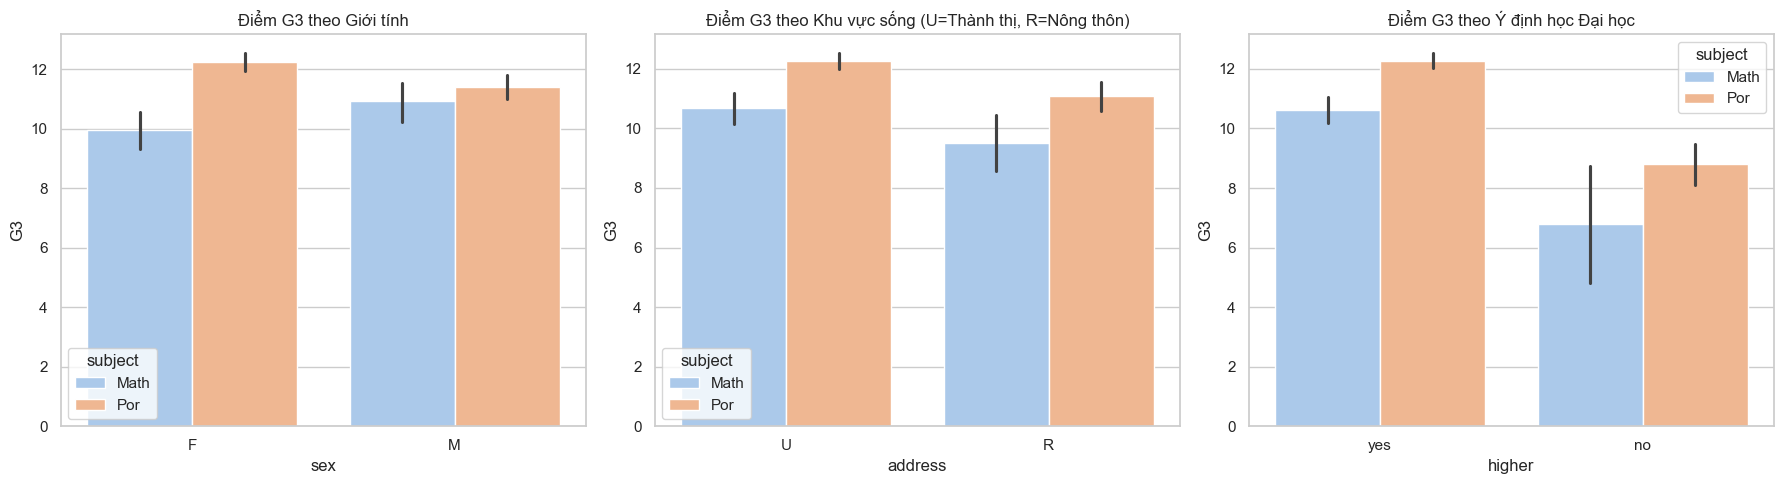

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(ax=axes[0], x='sex', y='G3', hue='subject', data=df, palette='pastel')
axes[0].set_title('Điểm G3 theo Giới tính')

sns.barplot(ax=axes[1], x='address', y='G3', hue='subject', data=df, palette='pastel')
axes[1].set_title('Điểm G3 theo Khu vực sống (U=Thành thị, R=Nông thôn)')

sns.barplot(ax=axes[2], x='higher', y='G3', hue='subject', data=df, palette='pastel')
axes[2].set_title('Điểm G3 theo Ý định học Đại học')

plt.tight_layout()
plt.show()

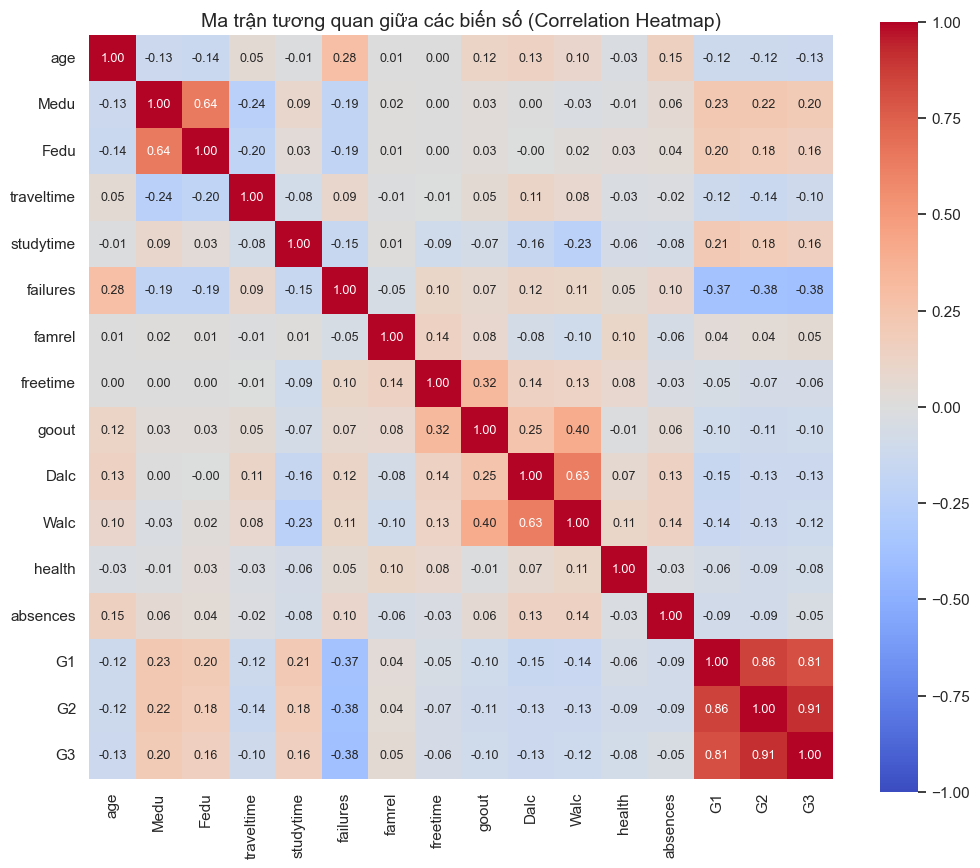

In [5]:
# Lọc ra chỉ các cột có kiểu dữ liệu là số
numeric_df = df.select_dtypes(include=[np.number])

# Tính toán ma trận tương quan
corr_matrix = numeric_df.corr()

# Vẽ Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar=True, square=True, vmin=-1, vmax=1, 
            annot_kws={"size": 9})

plt.title('Ma trận tương quan giữa các biến số (Correlation Heatmap)', fontsize=14)
plt.show()